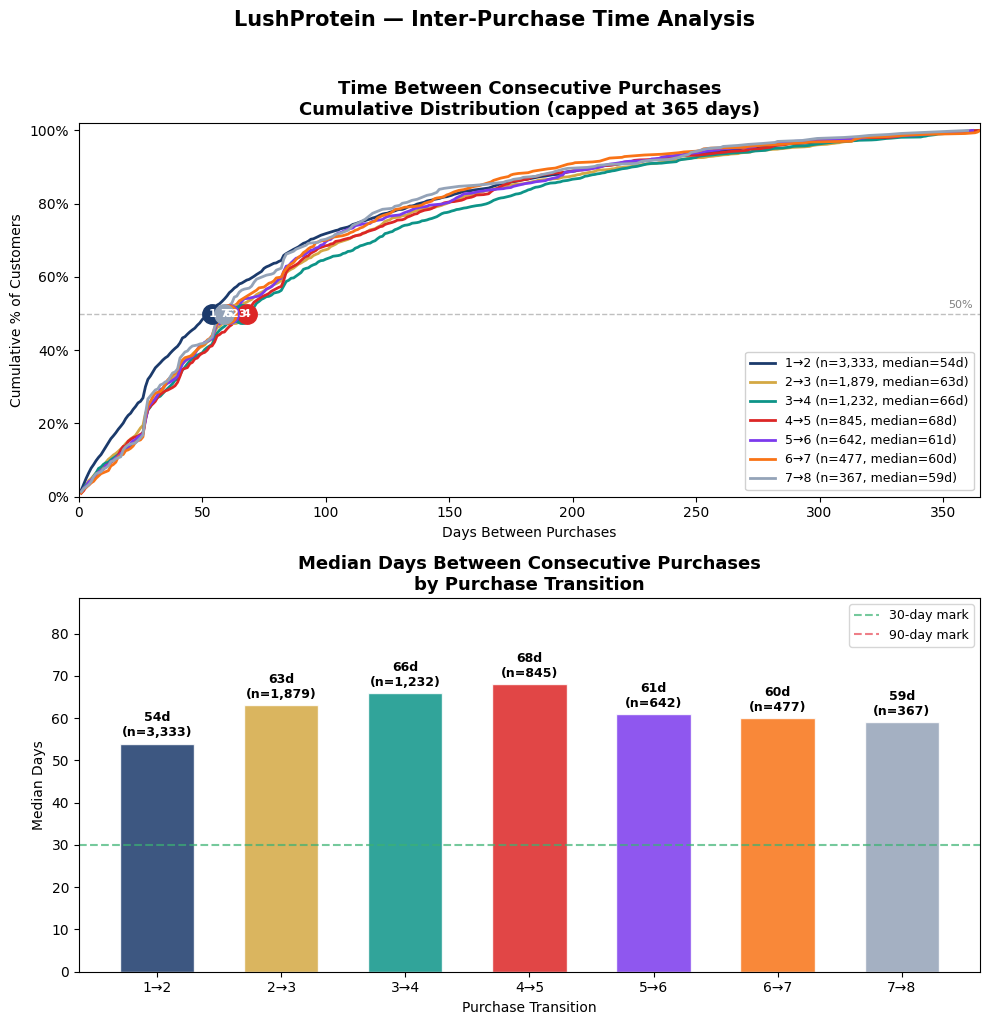

INTER-PURCHASE TIME — CONSECUTIVE TRANSITIONS
Transition        n    Median      Mean
----------------------------------------
1→2           3,333       54d       82d
2→3           1,879       63d       91d
3→4           1,232       66d       96d
4→5             845       68d       91d
5→6             642       61d       89d
6→7             477       60d       87d
7→8             367       59d       85d

⚠️  Note: LushProtein shows an inverted pattern vs typical retail.
   The 1→2 gap (54d) is shorter than 2→3 (63d) and 3→4 (66d),
   before gradually declining from 4→5 onward.
   This suggests the 1→2 transition is driven by highly motivated
   early returners, while mid-frequency customers take longer to commit.


In [5]:
# ── Inter-Purchase Time: Consecutive Purchase Transitions ─────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from pathlib import Path

SILVER_DIR = Path.cwd() / 'medallion' / 'silver'
COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'neutral'  : '#A8A8A8',
    'orange'   : '#F97316',
}

# ── Load and compute transitions ──────────────────────────────────────────────
silver = pd.read_parquet(SILVER_DIR / 'silver_orders.parquet')
top_rows = silver[silver['Top Row'].notna()].copy()
top_rows['Processed At'] = pd.to_datetime(top_rows['Processed At'],
                                           errors='coerce', utc=True)
top_rows = top_rows.dropna(subset=['Customer: ID', 'Processed At'])
top_rows = top_rows.sort_values(['Customer: ID', 'Processed At'])
top_rows['order_seq'] = top_rows.groupby('Customer: ID').cumcount() + 1

# Compute days to next order per customer
top_rows['next_order_date'] = top_rows.groupby('Customer: ID')['Processed At'].shift(-1)
top_rows['days_to_next']    = (top_rows['next_order_date'] - top_rows['Processed At']).dt.days
top_rows['transition']      = (top_rows['order_seq'].astype(str) + '→' +
                               (top_rows['order_seq'] + 1).astype(str))

# Keep valid transitions, cap at 365 days
transitions = top_rows[top_rows['days_to_next'].notna() &
                       (top_rows['days_to_next'] > 0) &
                       (top_rows['days_to_next'] <= 365)].copy()

# Focus on transitions with sufficient sample size (n >= 100)
TRANSITIONS = ['1→2', '2→3', '3→4', '4→5', '5→6', '6→7', '7→8']
transitions_filtered = transitions[transitions['transition'].isin(TRANSITIONS)]

# ── Build summary stats ───────────────────────────────────────────────────────
summary = (transitions_filtered.groupby('transition')['days_to_next']
           .agg(['count', 'median', 'mean'])
           .round(1)
           .reset_index())
summary.columns = ['transition', 'n', 'median', 'mean']

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Colour palette — one per transition
palette = ['#1B3A6B', '#D4A843', '#0D9488', '#DC2626',
           '#7C3AED', '#F97316', '#94A3B8']

# ── Panel 1: Cumulative distribution curves (like the reference chart) ─────
ax1 = axes[0]
ax1.axhline(50, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax1.text(362, 51, '50%', fontsize=8, color='grey', va='bottom', ha='right')

median_points = {}
for (transition, color) in zip(TRANSITIONS, palette):
    grp = transitions_filtered[transitions_filtered['transition'] == transition]
    if len(grp) < 50:
        continue
    n      = len(grp)
    median = grp['days_to_next'].median()

    sorted_days = grp['days_to_next'].sort_values().reset_index(drop=True)
    cumulative  = (sorted_days.rank(method='max') / len(sorted_days)) * 100

    ax1.plot(sorted_days, cumulative, color=color, linewidth=2,
             label=f'{transition} (n={n:,}, median={median:.0f}d)')
    median_points[transition] = (median, 50, color)

# Mark median points with numbered circles (like reference chart)
for i, (transition, (x, y, color)) in enumerate(median_points.items(), 1):
    ax1.plot(x, y, 'o', color=color, markersize=14, zorder=5)
    ax1.text(x, y, str(i), color='white', fontsize=8,
             fontweight='bold', ha='center', va='center', zorder=6)

ax1.set_title('Time Between Consecutive Purchases\nCumulative Distribution (capped at 365 days)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Days Between Purchases')
ax1.set_ylabel('Cumulative % of Customers')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xlim(0, 365)
ax1.set_ylim(0, 102)
ax1.legend(fontsize=9, loc='lower right', framealpha=0.9)

# ── Panel 2: Median IPT by transition — bar chart ─────────────────────────
ax2 = axes[1]

bars = ax2.bar(summary['transition'], summary['median'],
               color=palette[:len(summary)], alpha=0.85, edgecolor='white',
               width=0.6)

# Add data labels
for bar, (_, row) in zip(bars, summary.iterrows()):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f"{row['median']:.0f}d\n(n={int(row['n']):,})",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Reference line at 30 and 90 days
ax2.axhline(30, color=COLORS['accent'], linestyle='--',
            linewidth=1.5, alpha=0.7, label='30-day mark')
ax2.axhline(90, color=COLORS['secondary'], linestyle='--',
            linewidth=1.5, alpha=0.7, label='90-day mark')

ax2.set_title('Median Days Between Consecutive Purchases\nby Purchase Transition',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Purchase Transition')
ax2.set_ylabel('Median Days')
ax2.set_ylim(0, max(summary['median']) * 1.3)
ax2.legend(fontsize=9)

plt.suptitle('LushProtein — Inter-Purchase Time Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 55)
print("INTER-PURCHASE TIME — CONSECUTIVE TRANSITIONS")
print("=" * 55)
print(f"{'Transition':<12} {'n':>6}  {'Median':>8}  {'Mean':>8}")
print("-" * 40)
for _, row in summary.iterrows():
    print(f"{row['transition']:<12} {int(row['n']):>6,}  {row['median']:>7.0f}d  {row['mean']:>7.0f}d")

print(f"\n⚠️  Note: LushProtein shows an inverted pattern vs typical retail.")
print(f"   The 1→2 gap ({summary.loc[summary['transition']=='1→2','median'].values[0]:.0f}d) is shorter than 2→3 ({summary.loc[summary['transition']=='2→3','median'].values[0]:.0f}d) and 3→4 ({summary.loc[summary['transition']=='3→4','median'].values[0]:.0f}d),")
print(f"   before gradually declining from 4→5 onward.")
print(f"   This suggests the 1→2 transition is driven by highly motivated")
print(f"   early returners, while mid-frequency customers take longer to commit.")